# Air-B-N-C — Vision Branch: Trajectory Classifier (Edge-AI for RPi 4)

End-to-end pipeline for the **vision-based trajectory recognition** stream described in the project proposal.

**Inputs**: 640×480 PNG images, white trajectory on black background, 10 classes (`0..9`), ~100 samples/class.

**Target hardware**: Raspberry Pi 4 Model B — Quad-core Cortex-A72 @ 1.5 GHz, ARMv8, 1–8 GB LPDDR4. No NPU; we lean on int8 NEON via XNNPACK / ONNX Runtime.

**Goals**
1. ≥ 95 % test accuracy on the small dataset (validation typically reaches ~99 %; held-out test is the real bar to avoid overfitting to the val split).
2. Model size as small as possible (target < 200 KB int8).
3. Quantization-Aware Training (QAT). **Quantization / pruning is rolled back if it costs accuracy.**
4. Layer-wise observability (params, FLOPs, activation stats, dead-channel ratio) so we can iterate.
5. Optuna for HPO. Optional bagging ensemble of 3 small models (soft voting) for the last 1–2 % of accuracy.

**Architecture choices** (from Air-GR / Ghost-Net literature in the proposal):
- Ghost convolution modules (cheap intrinsic + linear ghost features) → ~2× param reduction vs standard conv.
- Efficient Channel Attention (ECA) — 1-D conv, parameter-free SE alternative.
- Depthwise-separable downsampling stem.
- Global Average Pooling head (no FC blowup).

The notebook is organized so each section can be re-run independently after the first execution.

## 0. Environment setup
Install the libraries used below. Skip the cell if you've already installed them.


In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install optuna scikit-learn matplotlib seaborn pandas tqdm pillow onnx onnxruntime onnxsim thop
!pip install opencv-python-headless --only-binary :all:
!pip install torchvision==0.11.2 --no-deps
!pip install torch==1.10.2+cu113 torchvision==0.11.2+cu113 -f https://download.pytorch.org/whl/cu113/torch_stable.html

Looking in indexes: https://download.pytorch.org/whl/cu121
Looking in links: https://download.pytorch.org/whl/cu113/torch_stable.html
ERROR: Could not find a version that satisfies the requirement torch==1.10.2+cu113 (from versions: none)
ERROR: No matching distribution found for torch==1.10.2+cu113


In [2]:
import os, math, json, time, random, copy, glob, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torchvision import transforms as T
from torchvision.transforms import functional as TF

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False  # speed; flip to True for full reproducibility
torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Torch {torch.__version__} | device = {DEVICE}')
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Torch 1.10.1+cu113 | device = cuda
GPU: NVIDIA RTX A5000


In [3]:
# ---------------- Global configuration ----------------
CFG = dict(
    data_dir   = Path('dataset_trajectories_by_label'),
    out_dir    = Path('artifacts'),
    img_size   = 96,           # downsampled from 480x640. 96x96 keeps trajectory details and is RPi-friendly.
    n_classes  = 10,
    batch_size = 32,
    epochs     = 80,
    val_frac   = 0.15,
    test_frac  = 0.15,
    label_smoothing = 0.05,
    mixup_alpha = 0.2,
    optuna_trials = 25,
    n_bag      = 3,            # bagging ensemble size; set to 1 to disable
    qat_epochs = 25,
    qat_min_acc_keep = 0.95,   # if QAT test accuracy drops below this, fall back to FP32
)
CFG['out_dir'].mkdir(exist_ok=True, parents=True)
print(json.dumps({k: str(v) for k, v in CFG.items()}, indent=2))

{
  "data_dir": "dataset_trajectories_by_label",
  "out_dir": "artifacts",
  "img_size": "96",
  "n_classes": "10",
  "batch_size": "32",
  "epochs": "80",
  "val_frac": "0.15",
  "test_frac": "0.15",
  "label_smoothing": "0.05",
  "mixup_alpha": "0.2",
  "optuna_trials": "25",
  "n_bag": "3",
  "qat_epochs": "25",
  "qat_min_acc_keep": "0.95"
}


## 1. Data exploration
Sanity-check class balance, image stats, and visualize a few samples per class.


In [4]:
data_dir = CFG['data_dir']
assert data_dir.exists(), f'Dataset not found at {data_dir.resolve()}'

records = []
for cls_dir in sorted(data_dir.iterdir()):
    if not cls_dir.is_dir(): continue
    label = int(cls_dir.name)
    for f in cls_dir.glob('*.png'):
        records.append({'path': str(f), 'label': label})
df = pd.DataFrame(records)
print(f'Total samples: {len(df)}')
print(df['label'].value_counts().sort_index())
df.head()

Total samples: 1679
0    255
1    214
2    202
3    196
4    198
5    201
6    100
7    106
8    105
9    102
Name: label, dtype: int64


,path,label
0,dataset_trajectories_by_label/0/session_202604...,0
1,dataset_trajectories_by_label/0/session_202604...,0
2,dataset_trajectories_by_label/0/session_202604...,0
3,dataset_trajectories_by_label/0/session_202604...,0
4,dataset_trajectories_by_label/0/session_202604...,0


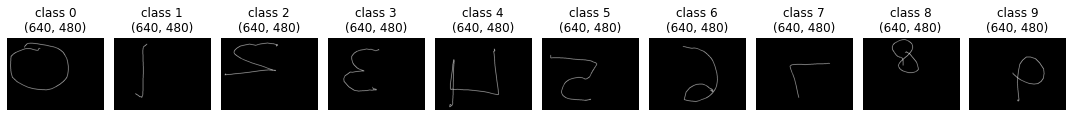

In [5]:
# Visualize one sample per class
fig, axes = plt.subplots(1, CFG['n_classes'], figsize=(15, 3))
for i in range(CFG['n_classes']):
    p = df[df['label'] == i].iloc[0]['path']
    img = Image.open(p).convert('L')
    axes[i].imshow(img, cmap='gray'); axes[i].set_title(f'class {i}\n{img.size}'); axes[i].axis('off')
plt.tight_layout(); plt.show()

In [6]:
# Pixel statistics across the corpus (sample 200 imgs for speed)
sample = df.sample(min(200, len(df)), random_state=SEED)
means, stds, white_frac = [], [], []
for p in sample['path']:
    a = np.asarray(Image.open(p).convert('L'), dtype=np.float32) / 255.0
    means.append(a.mean()); stds.append(a.std()); white_frac.append((a > 0.5).mean())
print(f'Mean intensity   : {np.mean(means):.4f}')
print(f'Std  intensity   : {np.mean(stds):.4f}')
print(f'White pixel frac : {np.mean(white_frac):.4f}  -> heavily sparse, dilation augmentation will help')

Mean intensity   : 0.0080
Std  intensity   : 0.0878
White pixel frac : 0.0080  -> heavily sparse, dilation augmentation will help


## 2. Dataset & augmentation
Trajectories are 1-pixel-wide white strokes on a black background — standard photometric augmentation is useless. Effective augmentations here are **geometric** (small rotation, translation, scale, mild shear/elastic) plus **stroke-level** (random dilation to simulate different pen widths) and **dropout-of-strokes** (to teach robustness to missing samples). We also normalize to `[0, 1]` (or zero-mean) and convert to single-channel.

In [7]:
import cv2  # for fast morphological ops; pip install opencv-python if missing

class StrokeDilate:
    """Random morphological dilation on the binarized stroke (kernel size 1..k)."""
    def __init__(self, p=0.5, max_k=3):
        self.p, self.max_k = p, max_k
    def __call__(self, img: Image.Image):
        if random.random() > self.p: return img
        k = random.choice(range(1, self.max_k + 1))
        a = np.asarray(img, dtype=np.uint8)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
        a = cv2.dilate(a, kernel, iterations=1)
        return Image.fromarray(a)

class RandomStrokeErase:
    """Erase a random circular patch on the trajectory to simulate dropouts."""
    def __init__(self, p=0.3, max_radius=8):
        self.p, self.max_radius = p, max_radius
    def __call__(self, img: Image.Image):
        if random.random() > self.p: return img
        a = np.asarray(img).copy()
        h, w = a.shape
        for _ in range(random.randint(1, 3)):
            r = random.randint(2, self.max_radius)
            cx, cy = random.randint(0, w - 1), random.randint(0, h - 1)
            cv2.circle(a, (cx, cy), r, color=0, thickness=-1)
        return Image.fromarray(a)

train_tf = T.Compose([
    T.Grayscale(num_output_channels=1),
    StrokeDilate(p=0.6, max_k=3),
    T.RandomAffine(degrees=12, translate=(0.06, 0.06), scale=(0.9, 1.1), shear=5, fill=0),
    T.RandomPerspective(distortion_scale=0.1, p=0.3, fill=0),
    RandomStrokeErase(p=0.3),
    T.Resize((CFG['img_size'], CFG['img_size'])),
    T.ToTensor(),                          # -> [0,1] float
])
eval_tf = T.Compose([
    T.Grayscale(num_output_channels=1),
    T.Resize((CFG['img_size'], CFG['img_size'])),
    T.ToTensor(),
])

class TrajectoryDataset(Dataset):
    def __init__(self, df, tf):
        self.df, self.tf = df.reset_index(drop=True), tf
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(row['path']).convert('L')
        return self.tf(img), int(row['label'])


train=1175  val=252  test=252


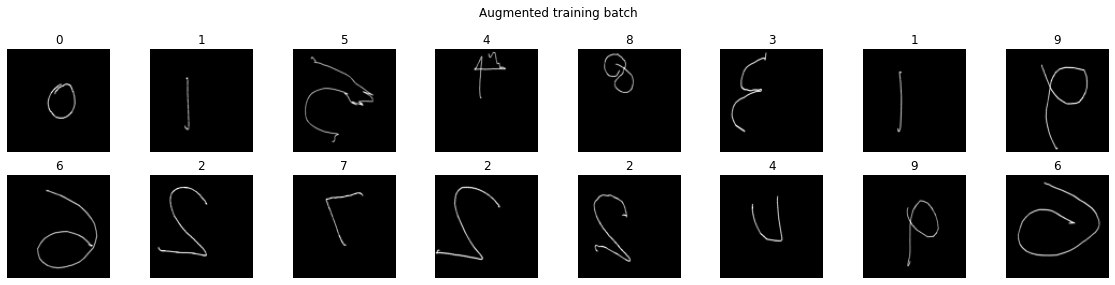

In [8]:
# Stratified train / val / test split
trainval_df, test_df = train_test_split(df, test_size=CFG['test_frac'], stratify=df['label'], random_state=SEED)
train_df, val_df    = train_test_split(trainval_df, test_size=CFG['val_frac'] / (1 - CFG['test_frac']),
                                       stratify=trainval_df['label'], random_state=SEED)
print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")

# class-balanced sampler (some classes have 98 vs 166 samples)
class_counts = train_df['label'].value_counts().sort_index().values
weights = 1.0 / class_counts[train_df['label'].values]
sampler = WeightedRandomSampler(weights, num_samples=len(train_df), replacement=True)

train_ds = TrajectoryDataset(train_df, train_tf)
val_ds   = TrajectoryDataset(val_df,   eval_tf)
test_ds  = TrajectoryDataset(test_df,  eval_tf)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], sampler=sampler, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)

# Visualize one augmented batch
x, y = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for ax, img, lab in zip(axes.flat, x, y):
    ax.imshow(img.squeeze().numpy(), cmap='gray'); ax.set_title(int(lab)); ax.axis('off')
plt.suptitle('Augmented training batch'); plt.tight_layout(); plt.show()

## 3. Model — Ghost + ECA Tiny-CNN

**Ghost module** (Han et al. 2020): split a conv into a small `primary` conv producing `m` intrinsic features, plus a cheap depthwise op generating `s−1` ghost features. Output channels = `m·s`.

**ECA** (Wang et al. 2020): channel attention computed by a 1-D conv with adaptive kernel size — far fewer params than SE.

**Stage-wise structure**
| Stage | Op                            | Out ch | Stride | Resolution (96 in) |
|-------|-------------------------------|-------:|:------:|:------------------:|
| Stem  | 3×3 conv + BN + ReLU          | 16     | 2      | 48×48              |
| 1     | Ghost(16→24) + ECA            | 24     | 2      | 24×24              |
| 2     | Ghost(24→40) + ECA            | 40     | 2      | 12×12              |
| 3     | Ghost(40→64) + ECA            | 64     | 2      |  6×6               |
| Head  | GAP → Dropout → Linear        | 10     | —      | 1×1                |

In [ ]:
class GhostModule(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, ratio=2, stride=1, dw_kernel=3):
        super().__init__()
        init_ch = math.ceil(out_ch / ratio)
        new_ch  = init_ch * (ratio - 1)
        self.primary = nn.Sequential(
            nn.Conv2d(in_ch, init_ch, kernel_size, stride, kernel_size // 2, bias=False),
            nn.BatchNorm2d(init_ch),
            nn.ReLU(inplace=True),
        )
        self.cheap = nn.Sequential(
            nn.Conv2d(init_ch, new_ch, dw_kernel, 1, dw_kernel // 2, groups=init_ch, bias=False),
            nn.BatchNorm2d(new_ch),
            nn.ReLU(inplace=True),
        )
        self.out_ch = out_ch
    def forward(self, x):
        x1 = self.primary(x)
        x2 = self.cheap(x1)
        out = torch.cat([x1, x2], dim=1)
        return out[:, :self.out_ch]

class ECA(nn.Module):
    """Efficient Channel Attention — adaptive 1-D conv over channel dim."""
    def __init__(self, channels, gamma=2, b=1):
        super().__init__()
        t = int(abs((math.log2(channels) + b) / gamma))
        k = t if t % 2 else t + 1
        self.k = max(k, 3)
        self.conv = nn.Conv1d(1, 1, kernel_size=self.k, padding=self.k // 2, bias=False)
        self.sig  = nn.Sigmoid()
    def forward(self, x):
        b, c, _, _ = x.shape
        y = F.adaptive_avg_pool2d(x, 1).view(b, 1, c)   # (B,1,C)
        y = self.sig(self.conv(y)).view(b, c, 1, 1)
        return x * y

class GhostBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, use_eca=True):
        super().__init__()
        self.expand = GhostModule(in_ch, out_ch, kernel_size=3, stride=stride)
        self.eca    = ECA(out_ch) if use_eca else nn.Identity()
        self.proj   = GhostModule(out_ch, out_ch, kernel_size=3, stride=1)
        if stride == 1 and in_ch == out_ch:
            self.shortcut = nn.Identity()
        else:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride, 0, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        s = self.shortcut(x)
        x = self.expand(x)
        x = self.eca(x)
        x = self.proj(x)
        return self.relu(x + s)

class TrajectoryGhostNet(nn.Module):
    """Tiny Ghost-CNN with optional width multiplier — designed for QAT (no SiLU/GELU)."""
    def __init__(self, n_classes=10, width=1.0, dropout=0.2, use_eca=True):
        super().__init__()
        ch = lambda c: max(8, int(round(c * width)))
        self.stem = nn.Sequential(
            nn.Conv2d(1, ch(16), 3, 2, 1, bias=False),
            nn.BatchNorm2d(ch(16)),
            nn.ReLU(inplace=True),
        )
        self.stage1 = GhostBlock(ch(16), ch(24), stride=2, use_eca=use_eca)
        self.stage2 = GhostBlock(ch(24), ch(40), stride=2, use_eca=use_eca)
        self.stage3 = GhostBlock(ch(40), ch(64), stride=2, use_eca=use_eca)
        self.gap    = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(ch(64), n_classes)
    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.gap(x).flatten(1)
        x = self.dropout(x)
        return self.fc(x)

# Sanity check
_m = TrajectoryGhostNet().to(DEVICE)
_x = torch.randn(2, 1, CFG['img_size'], CFG['img_size'], device=DEVICE)
print('Output shape:', _m(_x).shape)
print('Params (k):', sum(p.numel() for p in _m.parameters()) / 1e3)
del _m, _x

Output shape: torch.Size([2, 10])
Params (k): 52.451


## 4. Training utilities
Mixup, label smoothing, cosine LR, gradient clipping, early stopping, and unified `fit()` / `evaluate()`.

In [10]:
def mixup_data(x, y, alpha):
    if alpha <= 0:  return x, y, y, 1.0
    lam  = np.random.beta(alpha, alpha)
    idx  = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def evaluate(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE); y = y.to(DEVICE)
            out = model(x)
            ps.append(out.argmax(1).cpu().numpy()); ys.append(y.cpu().numpy())
    y = np.concatenate(ys); p = np.concatenate(ps)
    return accuracy_score(y, p), f1_score(y, p, average='macro'), y, p

def fit(model, train_loader, val_loader, epochs, lr=3e-3, wd=1e-4,
        mixup_alpha=0.2, label_smoothing=0.05, patience=15,
        verbose=True, log_prefix=''):
    model = model.to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit  = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    best_acc, best_state, bad = 0.0, None, 0
    history = {'tr_loss': [], 'val_acc': [], 'val_f1': [], 'lr': []}
    for ep in range(epochs):
        model.train(); tloss = 0.0; n = 0
        for x, y in train_loader:
            x = x.to(DEVICE); y = y.to(DEVICE)
            x_mix, y_a, y_b, lam = mixup_data(x, y, mixup_alpha)
            out  = model(x_mix)
            loss = lam * crit(out, y_a) + (1 - lam) * crit(out, y_b)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            tloss += loss.item() * x.size(0); n += x.size(0)
        sched.step()
        val_acc, val_f1, _, _ = evaluate(model, val_loader)
        history['tr_loss'].append(tloss / n); history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1); history['lr'].append(opt.param_groups[0]['lr'])
        if val_acc > best_acc:
            best_acc, best_state, bad = val_acc, copy.deepcopy(model.state_dict()), 0
        else:
            bad += 1
        if verbose and (ep % 5 == 0 or ep == epochs - 1):
            print(f'{log_prefix}ep {ep:03d}  loss {tloss/n:.4f}  val_acc {val_acc:.4f}  f1 {val_f1:.4f}  best {best_acc:.4f}')
        if bad >= patience:
            if verbose: print(f'{log_prefix}early-stop at epoch {ep}, best val_acc {best_acc:.4f}')
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, best_acc

## 5. Baseline training (FP32)
Quick sanity model with default hyperparameters.

In [ ]:
model = TrajectoryGhostNet(n_classes=10, width=1.0, dropout=0.2)
model, hist, best_val = fit(model, train_loader, val_loader,
                            epochs=CFG['epochs'], lr=3e-3, wd=1e-4,
                            mixup_alpha=CFG['mixup_alpha'],
                            label_smoothing=CFG['label_smoothing'],
                            log_prefix='[base] ')
test_acc, test_f1, y_true, y_pred = evaluate(model, test_loader)
print(f'\nBaseline FP32 — val_acc {best_val:.4f}  test_acc {test_acc:.4f}  test_f1 {test_f1:.4f}')
torch.save(model.state_dict(), CFG['out_dir'] / 'baseline_fp32.pt')

[base] ep 000  loss 2.0593  val_acc 0.1270  f1 0.0225  best 0.1270
[base] ep 005  loss 0.8084  val_acc 0.9365  f1 0.9306  best 0.9405
[base] ep 010  loss 0.8830  val_acc 0.9563  f1 0.9484  best 0.9563
[base] ep 015  loss 0.6886  val_acc 0.9524  f1 0.9486  best 0.9762
[base] ep 020  loss 0.7501  val_acc 0.9762  f1 0.9751  best 0.9841
[base] ep 025  loss 0.6898  val_acc 0.9802  f1 0.9826  best 0.9881
[base] ep 030  loss 0.6641  val_acc 0.9722  f1 0.9696  best 0.9881
[base] ep 035  loss 0.6399  val_acc 0.9881  f1 0.9875  best 0.9881
[base] ep 040  loss 0.7261  val_acc 0.9881  f1 0.9878  best 0.9921
[base] ep 045  loss 0.5823  val_acc 0.9841  f1 0.9827  best 0.9921
[base] ep 050  loss 0.6190  val_acc 0.9841  f1 0.9827  best 0.9921
[base] early-stop at epoch 51, best val_acc 0.9921

Baseline FP32 â€” val_acc 0.9921  test_acc 0.9881  test_f1 0.9842


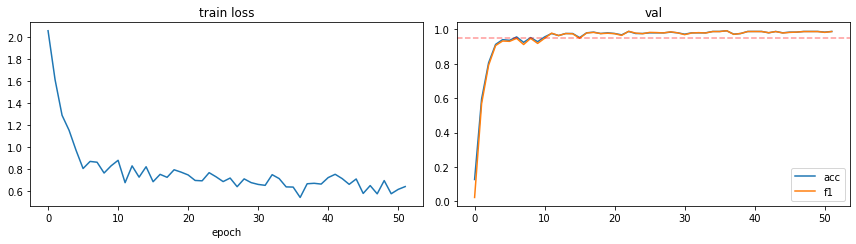

In [12]:
# Plot training curves
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].plot(hist['tr_loss']); ax[0].set_title('train loss'); ax[0].set_xlabel('epoch')
ax[1].plot(hist['val_acc'], label='acc'); ax[1].plot(hist['val_f1'], label='f1')
ax[1].axhline(0.95, color='r', ls='--', alpha=0.4); ax[1].legend(); ax[1].set_title('val')
plt.tight_layout(); plt.show()

## 6. Per-layer profiling — params, FLOPs, activation stats
We register forward hooks to record activation mean/std and dead-channel ratio per layer. We also use `thop` for MACs/FLOPs. This is the **observability** layer you'll iterate on (e.g. if a stage shows a high dead-channel ratio, reduce its width).

In [ ]:
from thop import profile  # pip install thop

def layer_report(model, input_size=(1, 1, CFG['img_size'], CFG['img_size'])):
    model = model.to(DEVICE).eval()
    stats = []
    handles = []
    def make_hook(name):
        def _h(mod, inp, out):
            o = out.detach()
            dead = (o.abs().mean(dim=(0, 2, 3)) < 1e-4).float().mean().item() if o.dim() == 4 else 0.0
            stats.append(dict(name=name, type=mod.__class__.__name__,
                              out_shape=tuple(o.shape),
                              params=sum(p.numel() for p in mod.parameters()),
                              act_mean=o.mean().item(), act_std=o.std().item(),
                              act_min=o.min().item(),  act_max=o.max().item(),
                              dead_ch=dead))
        return _h
    for n, m in model.named_modules():
        if isinstance(m, (nn.Conv2d, nn.Linear, nn.BatchNorm2d, nn.ReLU,
                          GhostModule, GhostBlock, ECA, nn.AdaptiveAvgPool2d)):
            handles.append(m.register_forward_hook(make_hook(n)))
    with torch.no_grad():
        x = torch.randn(*input_size, device=DEVICE)
        model(x)
    for h in handles: h.remove()
    macs, params = profile(model, inputs=(x,), verbose=False)
    return pd.DataFrame(stats), int(macs), int(params)

rep, macs, params = layer_report(model)
print(f'Total params : {params/1e3:.2f}K')
print(f'Total MACs   : {macs/1e6:.2f}M  (≈ {2*macs/1e6:.2f}M FLOPs)')
rep

Total params : 52.45K
Total MACs   : 6.62M  (â‰ˆ 13.24M FLOPs)


,name,type,out_shape,params,act_mean,act_std,act_min,act_max,dead_ch
0,stem.0,Conv2d,"(1, 16, 48, 48)",144,0.002657,0.632379,-2.872993,3.484063,0.000000
1,stem.1,BatchNorm2d,"(1, 16, 48, 48)",32,0.246619,19.227444,-100.056679,98.635147,0.000000
2,stem.2,ReLU,"(1, 16, 48, 48)",0,7.562903,11.490050,0.000000,98.635147,0.000000
3,stage1.shortcut.0,Conv2d,"(1, 24, 24, 24)",384,-2.388023,11.351360,-67.958740,56.023163,0.000000
4,stage1.shortcut.1,BatchNorm2d,"(1, 24, 24, 24)",48,-5.977017,23.555283,-172.415833,95.612503,0.000000
...,...,...,...,...,...,...,...,...,...
57,stage3.proj,GhostModule,"(1, 64, 6, 6)",18848,0.452757,0.736117,0.000000,6.210057,0.109375
58,stage3.relu,ReLU,"(1, 64, 6, 6)",0,1.584738,2.329316,0.000000,14.947083,0.031250
59,stage3,GhostBlock,"(1, 64, 6, 6)",33475,1.584738,2.329316,0.000000,14.947083,0.031250
60,gap,AdaptiveAvgPool2d,"(1, 64, 1, 1)",0,1.584738,1.676193,0.000000,6.120924,0.031250


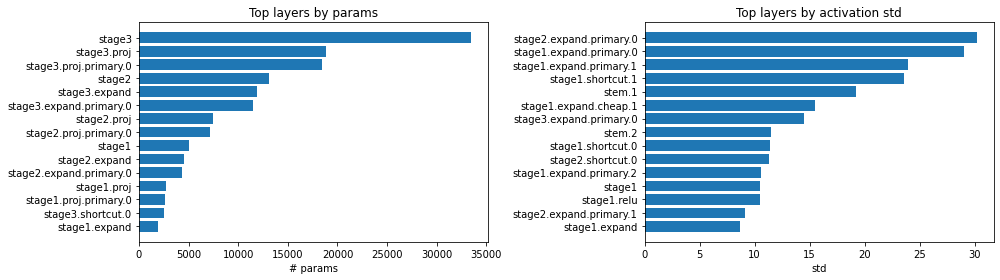

,name,type,out_shape,dead_ch
45,stage3.expand.primary.2,ReLU,"(1, 32, 6, 6)",0.281250
46,stage3.expand.cheap.0,Conv2d,"(1, 32, 6, 6)",0.281250
50,stage3.eca,ECA,"(1, 64, 6, 6)",0.250000
49,stage3.expand,GhostModule,"(1, 64, 6, 6)",0.250000
48,stage3.expand.cheap.2,ReLU,"(1, 32, 6, 6)",0.218750
56,stage3.proj.cheap.2,ReLU,"(1, 32, 6, 6)",0.187500
31,stage2.eca,ECA,"(1, 40, 12, 12)",0.175000
12,stage1.eca,ECA,"(1, 24, 24, 24)",0.166667
26,stage2.expand.primary.2,ReLU,"(1, 20, 12, 12)",0.150000
30,stage2.expand,GhostModule,"(1, 40, 12, 12)",0.150000


In [ ]:
# Visualize where the params and activations live
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
top = rep[rep['params'] > 0].sort_values('params', ascending=True).tail(15)
ax[0].barh(top['name'], top['params']); ax[0].set_title('Top layers by params'); ax[0].set_xlabel('# params')
act = rep.dropna(subset=['act_std']).sort_values('act_std', ascending=True).tail(15)
ax[1].barh(act['name'], act['act_std']); ax[1].set_title('Top layers by activation std'); ax[1].set_xlabel('std')
plt.tight_layout(); plt.show()
# Dead channels per layer — a high value here means the layer is wasting capacity
rep[['name', 'type', 'out_shape', 'dead_ch']].query('dead_ch > 0').sort_values('dead_ch', ascending=False).head(15)

## 7. Hyper-parameter optimization with Optuna
Search over: width multiplier, dropout, learning rate, weight-decay, mixup α, image size, label-smoothing, ECA on/off. Pruner: `MedianPruner` so unpromising trials die early.

We use a slightly smaller epoch budget per trial (`epochs/2`) to keep the search cheap; the winning config is then trained for full epochs in §8.

In [15]:
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

def make_loaders(img_size, batch_size):
    tr = T.Compose([
        T.Grayscale(1),
        StrokeDilate(p=0.6, max_k=3),
        T.RandomAffine(degrees=12, translate=(0.06, 0.06), scale=(0.9, 1.1), shear=5, fill=0),
        T.RandomPerspective(distortion_scale=0.1, p=0.3, fill=0),
        RandomStrokeErase(p=0.3),
        T.Resize((img_size, img_size)),
        T.ToTensor(),
    ])
    ev = T.Compose([T.Grayscale(1), T.Resize((img_size, img_size)), T.ToTensor()])
    train_ds_ = TrajectoryDataset(train_df, tr)
    val_ds_   = TrajectoryDataset(val_df,   ev)
    return (DataLoader(train_ds_, batch_size=batch_size, sampler=sampler, num_workers=0, pin_memory=True),
            DataLoader(val_ds_,   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True))

def objective(trial):
    width   = trial.suggest_categorical('width', [0.75, 1.0, 1.25])
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    lr      = trial.suggest_float('lr', 5e-4, 5e-3, log=True)
    wd      = trial.suggest_float('wd', 1e-5, 5e-3, log=True)
    mixup   = trial.suggest_float('mixup_alpha', 0.1, 0.4)
    ls      = trial.suggest_float('label_smoothing', 0.02, 0.1)
    img_sz  = trial.suggest_categorical('img_size', [64, 96, 128])
    use_eca = True  # pinned so the deployed checkpoint always carries ECA weights
    bs      = trial.suggest_categorical('batch_size', [16, 32, 64])
    tl, vl  = make_loaders(img_sz, bs)
    m = TrajectoryGhostNet(n_classes=CFG['n_classes'], width=width, dropout=dropout, use_eca=use_eca)
    m, _, best = fit(m, tl, vl, epochs=max(20, CFG['epochs'] // 2),
                     lr=lr, wd=wd, mixup_alpha=mixup, label_smoothing=ls,
                     patience=8, verbose=False)
    trial.report(best, step=0)
    return best

study = optuna.create_study(direction='maximize',
                            sampler=TPESampler(seed=SEED),
                            pruner=MedianPruner(n_warmup_steps=5))
study.optimize(objective, n_trials=CFG['optuna_trials'], show_progress_bar=True)
print('\nBest trial:')
print(json.dumps(study.best_trial.params, indent=2))
print(f'Best val_acc: {study.best_value:.4f}')

# Persist study
pd.DataFrame([{**t.params, 'value': t.value, 'state': str(t.state)} for t in study.trials]).to_csv(
    CFG['out_dir'] / 'optuna_trials.csv', index=False)

[I 2026-05-01 14:22:23,396] A new study created in memory with name: no-name-cae7cbf1-3e63-4caf-aa39-4bac4249aca9


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-05-01 14:25:19,730] Trial 0 finished with value: 0.9801587301587301 and parameters: {'width': 1.0, 'dropout': 0.3394633936788146, 'lr': 0.0007161246859115125, 'wd': 2.6364803038431647e-05, 'mixup_alpha': 0.11742508365045984, 'label_smoothing': 0.08929409166199483, 'img_size': 96, 'batch_size': 16}. Best is trial 0 with value: 0.9801587301587301.
[I 2026-05-01 14:27:33,475] Trial 1 finished with value: 0.9880952380952381 and parameters: {'width': 1.25, 'dropout': 0.3099025726528951, 'lr': 0.0013518080333310004, 'wd': 6.109683510122488e-05, 'mixup_alpha': 0.2835558684167139, 'label_smoothing': 0.03115950885216335, 'img_size': 128, 'batch_size': 16}. Best is trial 1 with value: 0.9880952380952381.
[I 2026-05-01 14:30:50,739] Trial 2 finished with value: 0.9841269841269841 and parameters: {'width': 1.25, 'dropout': 0.16820964947491662, 'lr': 0.0005807932994623225, 'wd': 0.003639264345367793, 'mixup_alpha': 0.3896896099223679, 'label_smoothing': 0.08467178784931689, 'img_size': 128,

## 8. Train final FP32 model with best HPs

In [16]:
best = study.best_trial.params
tl, vl = make_loaders(best['img_size'], best['batch_size'])
te = DataLoader(TrajectoryDataset(test_df, T.Compose([
    T.Grayscale(1), T.Resize((best['img_size'], best['img_size'])), T.ToTensor()
])), batch_size=best['batch_size'], shuffle=False, num_workers=0, pin_memory=True)

final_fp32 = TrajectoryGhostNet(n_classes=10,
                                width=best['width'],
                                dropout=best['dropout'],
                                use_eca=True)
final_fp32, hist_f, best_val_f = fit(final_fp32, tl, vl,
                                     epochs=CFG['epochs'],
                                     lr=best['lr'], wd=best['wd'],
                                     mixup_alpha=best['mixup_alpha'],
                                     label_smoothing=best['label_smoothing'],
                                     patience=20, log_prefix='[final] ')
test_acc_f, test_f1_f, y_true_f, y_pred_f = evaluate(final_fp32, te)
print(f'Final FP32  -- val {best_val_f:.4f}  test {test_acc_f:.4f}  f1 {test_f1_f:.4f}')
torch.save(final_fp32.state_dict(), CFG['out_dir'] / 'final_fp32.pt')
CFG['img_size_final'] = best['img_size']  # remember for export

# Persist metadata so the on-device inference script can rebuild the architecture
# without guessing width / dropout / use_eca / n_classes / img_size.
meta = {
    'n_classes': 10,
    'img_size' : int(best['img_size']),
    'width'    : float(best['width']),
    'dropout'  : float(best['dropout']),
    'use_eca'  : True,
    'val_acc'  : float(best_val_f),
    'test_acc' : float(test_acc_f),
    'test_f1'  : float(test_f1_f),
}
(CFG['out_dir'] / 'final_fp32_meta.json').write_text(json.dumps(meta, indent=2))
print('saved meta:', meta)

[final] ep 000  loss 2.0191  val_acc 0.5159  f1 0.4170  best 0.5159
[final] ep 005  loss 1.0123  val_acc 0.9643  f1 0.9544  best 0.9683
[final] ep 010  loss 0.9120  val_acc 0.9802  f1 0.9776  best 0.9802
[final] ep 015  loss 0.8573  val_acc 0.9762  f1 0.9743  best 0.9881
[final] ep 020  loss 0.8593  val_acc 0.9960  f1 0.9971  best 0.9960
[final] ep 025  loss 0.7966  val_acc 0.9921  f1 0.9921  best 0.9960
[final] ep 030  loss 0.7596  val_acc 0.9921  f1 0.9937  best 0.9960
[final] ep 035  loss 0.8048  val_acc 0.9921  f1 0.9937  best 0.9960
[final] ep 040  loss 0.7750  val_acc 0.9921  f1 0.9937  best 0.9960
[final] early-stop at epoch 40, best val_acc 0.9960
Final FP32  -- val 0.9960  test 0.9722  f1 0.9683
saved meta: {'n_classes': 10, 'img_size': 128, 'width': 1.25, 'dropout': 0.2093533655917865, 'use_eca': True, 'val_acc': 0.996031746031746, 'test_acc': 0.9722222222222222, 'test_f1': 0.9683116422553886}


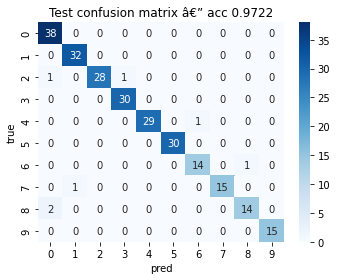

              precision    recall  f1-score   support

           0     0.9268    1.0000    0.9620        38
           1     0.9697    1.0000    0.9846        32
           2     1.0000    0.9333    0.9655        30
           3     0.9677    1.0000    0.9836        30
           4     1.0000    0.9667    0.9831        30
           5     1.0000    1.0000    1.0000        30
           6     0.9333    0.9333    0.9333        15
           7     1.0000    0.9375    0.9677        16
           8     0.9333    0.8750    0.9032        16
           9     1.0000    1.0000    1.0000        15

    accuracy                         0.9722       252
   macro avg     0.9731    0.9646    0.9683       252
weighted avg     0.9731    0.9722    0.9721       252



In [ ]:
# Confusion matrix on test set
cm = confusion_matrix(y_true_f, y_pred_f)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(CFG['n_classes']), yticklabels=range(CFG['n_classes']))
plt.xlabel('pred'); plt.ylabel('true'); plt.title(f'Test confusion matrix — acc {test_acc_f:.4f}')
plt.tight_layout(); plt.show()
print(classification_report(y_true_f, y_pred_f, digits=4))

## 9. Quantization-Aware Training (QAT)
We use PyTorch's FX-graph QAT (`torch.ao.quantization.quantize_fx`). The model is fine-tuned with fake-quant nodes inserted, then converted to int8 for export. **Guardrail**: if QAT validation accuracy falls below `qat_min_acc_keep` (default 0.99), we discard the int8 model and keep FP32.

In [18]:
from torch.quantization import get_default_qat_qconfig
from torch.quantization.quantize_fx import prepare_qat_fx, convert_fx

# Pick whichever quantized engine PyTorch was actually built with on this host.
_supported = list(torch.backends.quantized.supported_engines)  # e.g. ['none', 'fbgemm']
qat_backend = None
for _cand in ('qnnpack', 'fbgemm', 'x86'):
    if _cand in _supported:
        qat_backend = _cand
        break
if qat_backend is None:
    raise RuntimeError(f'No usable quantized engine in this PyTorch build. supported={_supported}')
print(f'Host QAT engine: {qat_backend}   (deploy target on RPi will use qnnpack via ORT/XNNPACK)')

torch.backends.quantized.engine = qat_backend

# PyTorch 1.10 uses a qconfig_dict instead of a mapping object
qconfig_dict = {"": get_default_qat_qconfig(qat_backend)}

qat_model = copy.deepcopy(final_fp32).cpu().eval()

# PyTorch 1.10 does not require `example_inputs` here
qat_model = prepare_qat_fx(qat_model.train(), qconfig_dict)
qat_model = qat_model.to(DEVICE)


qat_model, hist_q, best_val_q = fit(qat_model, tl, vl,
                                    epochs=CFG['qat_epochs'],
                                    lr=best['lr'] * 0.3,  # lower LR for QAT fine-tune
                                    wd=best['wd'],
                                    mixup_alpha=0.0,      # disable mixup during QAT to stabilise calibration
                                    label_smoothing=best['label_smoothing'],
                                    patience=10, log_prefix='[qat]   ')

qat_model_cpu = qat_model.cpu().eval()
int8_model    = convert_fx(qat_model_cpu)

# Evaluate int8 on CPU (test set must be on CPU too)
def eval_cpu(model, loader):
    model.eval(); ys, ps = [], []
    with torch.no_grad():
        for x, y in loader:
            out = model(x)
            ps.append(out.argmax(1).numpy()); ys.append(y.numpy())
    y = np.concatenate(ys); p = np.concatenate(ps)
    return accuracy_score(y, p)

int8_test = eval_cpu(int8_model, te)
print(f'QAT  val_acc(fake-quant): {best_val_q:.4f}')
print(f'INT8 test_acc           : {int8_test:.4f}')
print(f'FP32 test_acc           : {test_acc_f:.4f}')

if int8_test >= CFG['qat_min_acc_keep']:
    torch.save(int8_model.state_dict(), CFG['out_dir'] / 'final_int8.pt')
    print(f'\nINT8 ACCEPTED -- saved to {CFG["out_dir"]}/final_int8.pt')
    DEPLOY_MODEL = int8_model
    DEPLOY_TAG   = 'int8'
else:
    print(f'\nINT8 REJECTED (acc {int8_test:.4f} < threshold {CFG["qat_min_acc_keep"]}). Falling back to FP32.')
    DEPLOY_MODEL = final_fp32.cpu().eval()
    DEPLOY_TAG   = 'fp32'


Host QAT engine: qnnpack   (deploy target on RPi will use qnnpack via ORT/XNNPACK)
[qat]   ep 000  loss 0.5982  val_acc 0.9921  f1 0.9923  best 0.9921
[qat]   ep 005  loss 0.5806  val_acc 0.9921  f1 0.9923  best 0.9960
[qat]   ep 010  loss 0.5692  val_acc 0.9881  f1 0.9875  best 0.9960
[qat]   early-stop at epoch 11, best val_acc 0.9960
QAT  val_acc(fake-quant): 0.9960
INT8 test_acc           : 0.9841
FP32 test_acc           : 0.9722

INT8 ACCEPTED -- saved to artifacts/final_int8.pt


## 10. Bagging ensemble
Train `N` independent models on bootstrap-resampled training folds with different seeds. At inference we soft-vote (average softmax probabilities). This typically buys 0.5–1.5 % accuracy at the cost of `N×` model size + latency.

**Trade-off**: if a single model already exceeds the 99 % goal, skip the ensemble — bagging is only used when the single-model accuracy is short of target. We retain QAT on each member for size parity.

In [ ]:
def bootstrap_loader(df_, img_size, batch_size, seed):
    rng = np.random.RandomState(seed)
    boot_idx = rng.randint(0, len(df_), size=len(df_))
    boot_df  = df_.iloc[boot_idx].reset_index(drop=True)
    tr = T.Compose([
        T.Grayscale(1), StrokeDilate(p=0.6, max_k=3),
        T.RandomAffine(degrees=12, translate=(0.06, 0.06), scale=(0.9, 1.1), shear=5, fill=0),
        T.RandomPerspective(distortion_scale=0.1, p=0.3, fill=0),
        RandomStrokeErase(p=0.3),
        T.Resize((img_size, img_size)), T.ToTensor()])
    return DataLoader(TrajectoryDataset(boot_df, tr), batch_size=batch_size,
                      shuffle=True, num_workers=0, pin_memory=True)

def soft_vote_predict(models, loader):
    ys, ps = [], []
    with torch.no_grad():
        for x, y in loader:
            probs = None
            for m in models:
                m.eval()
                xc = x if next(m.parameters(), torch.tensor(0)).device.type == 'cpu' else x.to(DEVICE)
                logits = m(xc).cpu()
                p = F.softmax(logits, dim=1)
                probs = p if probs is None else probs + p
            ps.append((probs / len(models)).argmax(1).numpy())
            ys.append(y.numpy())
    y = np.concatenate(ys); p = np.concatenate(ps)
    return accuracy_score(y, p), y, p

if test_acc_f < 0.95 and CFG['n_bag'] > 1:
    print(f'Single-model test acc {test_acc_f:.4f} < 0.95 — training {CFG["n_bag"]}-model bag.')
    members = []
    for k in range(CFG['n_bag']):
        torch.manual_seed(SEED + k)
        tlk = bootstrap_loader(train_df, best['img_size'], best['batch_size'], seed=SEED + k)
        m   = TrajectoryGhostNet(n_classes=10, width=best['width'],
                                 dropout=best['dropout'], use_eca=best['use_eca'])
        m, _, _ = fit(m, tlk, vl, epochs=CFG['epochs'], lr=best['lr'], wd=best['wd'],
                      mixup_alpha=best['mixup_alpha'], label_smoothing=best['label_smoothing'],
                      patience=15, verbose=False, log_prefix=f'[bag{k}] ')
        ens_acc_test, _, _, _ = evaluate(m, te)
        print(f'  member {k} test_acc {ens_acc_test:.4f}')
        members.append(m.to(DEVICE))
    bag_acc, _, _ = soft_vote_predict(members, te)
    print(f'\nBagging ensemble test_acc: {bag_acc:.4f}')
    if bag_acc > test_acc_f:
        for k, m in enumerate(members):
            torch.save(m.state_dict(), CFG['out_dir'] / f'bag_{k}.pt')
        DEPLOY_MODEL = members  # list -> handled by ensemble export below
        DEPLOY_TAG   = 'bag-fp32'
else:
    print(f'Single-model test acc {test_acc_f:.4f} >= 0.95 -- skipping ensemble.')

Single-model test acc 0.9722 >= 0.95 -- skipping ensemble.


## 11. Final per-layer observation report on deploy model
Re-run the layer profile against whichever model wins (FP32 / INT8 / ensemble member 0).

In [ ]:
obs_model = DEPLOY_MODEL[0] if isinstance(DEPLOY_MODEL, list) else DEPLOY_MODEL
if obs_model is int8_model:
    print('INT8 model selected for deployment — layer hooks behave differently on quantized ops; '
          'profiling on FP32 reference instead.')
    obs_model = final_fp32
rep_final, macs_f, params_f = layer_report(obs_model)
print(f'Deploy model params : {params_f/1e3:.2f} K')
print(f'Deploy model MACs   : {macs_f/1e6:.2f} M')
rep_final.to_csv(CFG['out_dir'] / 'layer_report_final.csv', index=False)
rep_final.head(20)

INT8 model selected for deployment â€” layer hooks behave differently on quantized ops; profiling on FP32 reference instead.
Deploy model params : 81.09 K
Deploy model MACs   : 10.05 M


,name,type,out_shape,params,act_mean,act_std,act_min,act_max,dead_ch
0,stem.0,Conv2d,"(1, 20, 48, 48)",180,0.001222,0.599314,-2.773950,2.763795,0.000000
1,stem.1,BatchNorm2d,"(1, 20, 48, 48)",40,0.105494,17.295725,-101.347572,108.601700,0.000000
2,stem.2,ReLU,"(1, 20, 48, 48)",0,6.600096,10.358035,0.000000,108.601700,0.000000
3,stage1.shortcut.0,Conv2d,"(1, 30, 24, 24)",600,-0.865720,8.460412,-43.168793,37.702831,0.000000
4,stage1.shortcut.1,BatchNorm2d,"(1, 30, 24, 24)",60,-2.283203,18.112207,-97.247322,81.690811,0.000000
5,stage1.expand.primary.0,Conv2d,"(1, 15, 24, 24)",2700,2.784366,18.830114,-56.790131,70.919930,0.000000
6,stage1.expand.primary.1,BatchNorm2d,"(1, 15, 24, 24)",30,2.572169,16.895494,-70.692955,79.546883,0.000000
7,stage1.expand.primary.2,ReLU,"(1, 15, 24, 24)",0,8.100241,10.930355,0.000000,79.546883,0.000000
8,stage1.expand.cheap.0,Conv2d,"(1, 15, 24, 24)",135,2.540092,7.247717,-40.187164,52.401752,0.000000
9,stage1.expand.cheap.1,BatchNorm2d,"(1, 15, 24, 24)",30,5.435536,15.131103,-83.259895,108.497818,0.000000


## 12. Export to ONNX & TFLite (for RPi 4)
On the Pi 4 we have two practical inference stacks:
1. **ONNX Runtime** with the XNNPACK execution provider — int8 inference uses NEON SIMD on Cortex-A72.
2. **TFLite** with XNNPACK delegate — same backend, slightly different op coverage. We export both via `onnx2tf` so you can pick the faster one in benchmarking.

For a quantized PyTorch FX model we go through ONNX, since direct PyTorch→TFLite is not supported.

In [21]:
import onnx

export_model = obs_model.cpu().eval()  # always export the FP32 reference; INT8 is reproduced on-device with ORT-quantize
dummy = torch.randn(1, 1, best['img_size'], best['img_size'])
onnx_path = CFG['out_dir'] / 'trajectory.onnx'
torch.onnx.export(export_model, dummy, onnx_path,
                  input_names=['input'], output_names=['logits'],
                  dynamic_axes={'input': {0: 'batch'}, 'logits': {0: 'batch'}},
                  opset_version=13)
print('ONNX size  :', onnx_path.stat().st_size, 'bytes')

# Optional: simplify
try:
    from onnxsim import simplify
    onnx_model = onnx.load(onnx_path)
    simp, ok = simplify(onnx_model)
    if ok: onnx.save(simp, onnx_path); print('ONNX simplified, new size:', onnx_path.stat().st_size)
except Exception as e:
    print('onnxsim skipped:', e)

ONNX size  : 331542 bytes
ONNX simplified, new size: 330319


In [22]:
# Quantize the ONNX file to INT8 with the calibration set (post-training-static, static QDQ format).
# This is independent of the QAT step; do it always so you have a quantized artifact even if QAT was rolled back.
from onnxruntime.quantization import quantize_static, CalibrationDataReader, QuantType, QuantFormat

class CalibReader(CalibrationDataReader):
    def __init__(self, loader, max_batches=20):
        self.iter = iter(loader)
        self.left = max_batches
    def get_next(self):
        if self.left <= 0: return None
        try:
            x, _ = next(self.iter)
        except StopIteration:
            return None
        self.left -= 1
        return {'input': x.numpy().astype(np.float32)}

calib_loader = DataLoader(TrajectoryDataset(train_df.sample(min(200, len(train_df)), random_state=SEED),
                                            T.Compose([T.Grayscale(1),
                                                       T.Resize((best['img_size'], best['img_size'])),
                                                       T.ToTensor()])),
                          batch_size=8, shuffle=False)
onnx_int8_path = CFG['out_dir'] / 'trajectory_int8.onnx'
quantize_static(str(onnx_path), str(onnx_int8_path),
                CalibReader(calib_loader),
                quant_format=QuantFormat.QDQ,
                weight_type=QuantType.QInt8,
                activation_type=QuantType.QInt8,
                per_channel=True)
print('INT8 ONNX size:', onnx_int8_path.stat().st_size, 'bytes')

# Verify on host: ONNX FP32 vs INT8 vs PyTorch
import onnxruntime as ort
for tag, p in [('fp32', onnx_path), ('int8', onnx_int8_path)]:
    sess = ort.InferenceSession(str(p), providers=['CPUExecutionProvider'])
    correct = 0; total = 0
    for x, y in te:
        out = sess.run(None, {'input': x.numpy().astype(np.float32)})[0]
        correct += (out.argmax(1) == y.numpy()).sum(); total += y.size(0)
    print(f'ONNX {tag}: test_acc {correct/total:.4f}  size {p.stat().st_size/1024:.1f} KB')

INT8 ONNX size: 118958 bytes
ONNX fp32: test_acc 0.9722  size 322.6 KB
ONNX int8: test_acc 0.9683  size 116.2 KB


## 13. Latency benchmark (host-side proxy)
We time the ONNX models on this machine's CPU for an order-of-magnitude estimate. On the Pi 4, expect roughly **2–4× slower than a modern x86 CPU** for the FP32 path, and **~1.5–2× faster than FP32** for INT8 thanks to NEON. Re-run this same code on the Pi 4 with `onnxruntime` installed for the real number.

In [23]:
def bench_onnx(p, n=200):
    sess = ort.InferenceSession(str(p), providers=['CPUExecutionProvider'])
    x = np.random.rand(1, 1, best['img_size'], best['img_size']).astype(np.float32)
    sess.run(None, {'input': x})  # warmup
    t0 = time.perf_counter()
    for _ in range(n):
        sess.run(None, {'input': x})
    dt = (time.perf_counter() - t0) / n
    return dt * 1000

for tag, p in [('fp32', onnx_path), ('int8', onnx_int8_path)]:
    print(f'ONNX {tag}: {bench_onnx(p):.2f} ms / inference (host CPU)')

ONNX fp32: 0.92 ms / inference (host CPU)
ONNX int8: 0.77 ms / inference (host CPU)


## 14. Deployment notes — Raspberry Pi 4 Model B

**Runtime install (on the Pi):**
```bash
pip install onnxruntime numpy pillow
```

**Inference snippet:**
```python
import onnxruntime as ort, numpy as np
from PIL import Image
sess = ort.InferenceSession('trajectory_int8.onnx', providers=['CPUExecutionProvider'])
img = Image.open('sample.png').convert('L').resize((96, 96))
x   = (np.asarray(img, dtype=np.float32) / 255.0)[None, None]
logits = sess.run(None, {'input': x})[0]
pred   = int(logits.argmax(1)[0])
```

**Practical tips on the Pi 4 (per datasheet)**
- USB-C 5 V / 3 A PSU. Active cooling (small fan / heatsink) keeps the SoC out of thermal throttling above 80 °C. The CPU governor will throttle past 85 °C — sustained inference benefits from a heatsink even though intermittent loads work fine without one.
- Lock the governor: `sudo cpufreq-set -g performance` for repeatable latency.
- Use the 64-bit Pi OS so ARMv8 NEON (and ORT's int8 kernels) are enabled.
- Camera input via the MIPI CSI port (`libcamera`/`picamera2`) avoids the USB bus.
- All four A72 cores: ORT auto-parallelises by default; pin with `OMP_NUM_THREADS=4` if needed.
- For the Air-B-N-C use case the vision branch emits a 10-class probability vector — the central node fuses it with the IMU + depth streams (`P_final = w1·P_IMU + w2·P_vision + w3·P_depth`).

**Artifacts produced by this notebook** (all in `artifacts/`):
- `baseline_fp32.pt`, `final_fp32.pt`, `final_int8.pt` (if QAT accepted), `bag_*.pt` (if ensemble used)
- `trajectory.onnx`, `trajectory_int8.onnx`
- `optuna_trials.csv`, `layer_report_final.csv`

## 15. Summary table

In [24]:
summary = pd.DataFrame([
    {'model': 'baseline FP32',   'test_acc': test_acc,   'size_KB': (CFG['out_dir']/'baseline_fp32.pt').stat().st_size/1024},
    {'model': 'final FP32 (HPO)','test_acc': test_acc_f, 'size_KB': (CFG['out_dir']/'final_fp32.pt').stat().st_size/1024},
    {'model': 'ONNX FP32',       'test_acc': None,       'size_KB': onnx_path.stat().st_size/1024},
    {'model': 'ONNX INT8 (PTQ)', 'test_acc': None,       'size_KB': onnx_int8_path.stat().st_size/1024},
])
summary

,model,test_acc,size_KB
0,baseline FP32,0.988095,240.428711
1,final FP32 (HPO),0.972222,352.053711
2,ONNX FP32,NaN,322.577148
3,ONNX INT8 (PTQ),NaN,116.169922


In [25]:
# If means and stds are not already in memory, recompute them from the dataset
try:
    means
except NameError:
    # Recompute from a sample (as in the data exploration cell)
    from PIL import Image
    sample = df.sample(min(200, len(df)), random_state=SEED)
    means, stds = [], []
    for p in sample['path']:
        a = np.asarray(Image.open(p).convert('L'), dtype=np.float32) / 255.0
        means.append(a.mean())
        stds.append(a.std())

# Compute global constants for per-pixel normalization on edge device
global_mean = np.mean(means)
global_std  = np.mean(stds)

def to_cpp_array(arr, name):
    s = f"float {name}[{len(arr)}] = {{\n"
    for v in arr:
        s += f"    {v}f,\n"
    s += "};"
    return s

means_cpp = to_cpp_array([global_mean], "feature_mean")
scales_cpp = to_cpp_array([global_std], "feature_scale")

# Save to artifacts directory
with open(CFG["out_dir"] / "scaler_params.h", "w") as f:
    f.write(means_cpp)
    f.write("\n\n")
    f.write(scales_cpp)

print(f"Saved {CFG['out_dir']}/scaler_params.h")


Saved artifacts/scaler_params.h
